# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [1]:
from pathlib import Path

import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score
import warnings
warnings.filterwarnings("ignore")

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage

In [2]:
# Read prices, compute daily simple returns
data_path = Path("") #To change user by user please do not commit or push it
last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
performance = last_prices.pct_change().iloc[1:]

In [3]:
# Estimation parameters
estimation_window = 252*2 #ERROR substitute with the correct estimation window length
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)


## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [4]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}  # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()
    universes[reb] = diag["retained_assets"] # !!! COMPLETE AS APPROPRIATE !!!
    mkt_return_proxy = cur_returns.mean(axis = 1)
    covariances[reb] = {"sample" : cur_returns.cov(),
                        "constant_corr" : constant_corr_shrinkage(cur_returns)["shrunk_cov"], 
                        "mkt_factor" : market_factor_shrinkage(cur_returns, mkt_return_proxy)["shrunk_cov"]
                        } # !!! COMPLETE AS APPROPRIATE !!!

all_dates = sorted(covariances.keys())

In [5]:
covs = covariances[dt.date(2014,12,31)]
print(np.linalg.norm(covs["mkt_factor"].values - covs["sample"].values, "fro"))
print(np.linalg.norm(covs["mkt_factor"].values - covs["constant_corr"].values, "fro"))
print(np.linalg.norm(covs["constant_corr"].values - covs["sample"].values, "fro"))

0.0001245267198337695
0.00013020494710330792
0.00014855772957595952


## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


In [6]:
iv_erc_delta = {}
erc_normalized_range = {}
for date in all_dates:
    inv_ptfg = inverse_volatility_portfolio(np.diagflat(np.diag(covariances[date]["sample"]))) 
    erc_ptfg = equal_risk_contribution_portfolio(np.diagflat(np.diag(covariances[date]["sample"])))
  
    iv_erc_delta[date] = abs(inv_ptfg - erc_ptfg ) # !!! COMPLETE AS APPROPRIATE !!!
    erc_normalized_range[date] = max(erc_ptfg) - min(erc_ptfg) # !!! COMPLETE AS APPROPRIATE !!!
    
print(np.max([np.max(delta) for delta in iv_erc_delta.values()]))

0.0


### 1.c ERC backtest across the three covariance estimators


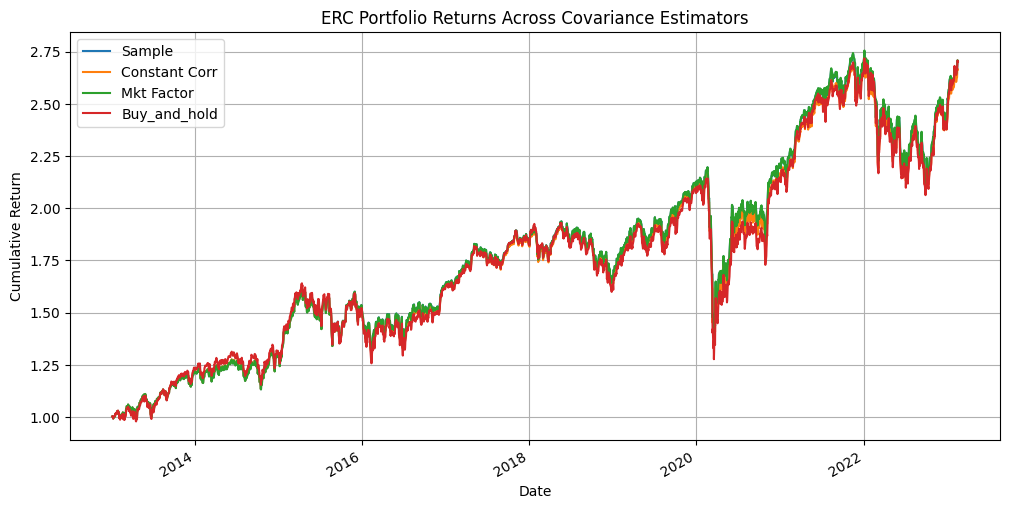

In [7]:
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}, "buy and hold" : {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov in covariances[reb].items():
        weights = equal_risk_contribution_portfolio(covariance= np.array(cov)) 
        erc_portfolios[est_name][reb] = pd.Series(weights, index=universe)
    # Equal-weighted buy and hold portfolio
    buy_hold_weights = np.ones(len(universe)) / len(universe)
    erc_portfolios["buy and hold"][reb] = pd.Series(buy_hold_weights, index=universe)

# Build one DataFrame per estimator: index=dates, columns=assets
erc_dfs = {
    est_name: pd.DataFrame(weights_by_date).T   # dates as rows, assets as cols
    for est_name, weights_by_date in erc_portfolios.items()
}

df_sample = erc_dfs["sample"].fillna(0)
df_constant_corr = erc_dfs["constant_corr"].fillna(0)
df_mkt_factor = erc_dfs["mkt_factor"].fillna(0)
df_buy_hold = erc_dfs["buy and hold"].fillna(0)

returns_sample = backtest(df_sample, performance, transaction_costs=10e-4)
returns_cst_cor = backtest(df_constant_corr, performance, transaction_costs=10e-4)
return_mkt_factor = backtest(df_mkt_factor, performance,  transaction_costs=10e-4)
return_bh = backtest(df_buy_hold, performance,  transaction_costs=10e-4)

# Create a DataFrame with the three return series
erc_returns = pd.DataFrame({
    'Sample': returns_sample ,
    'Constant Corr': returns_cst_cor,
    'Mkt Factor': return_mkt_factor,
    "Buy_and_hold" : return_bh
})

# Plot the cumulative returns
erc_returns.plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('ERC Portfolio Returns Across Covariance Estimators')
plt.legend()
plt.grid(True)
plt.show()

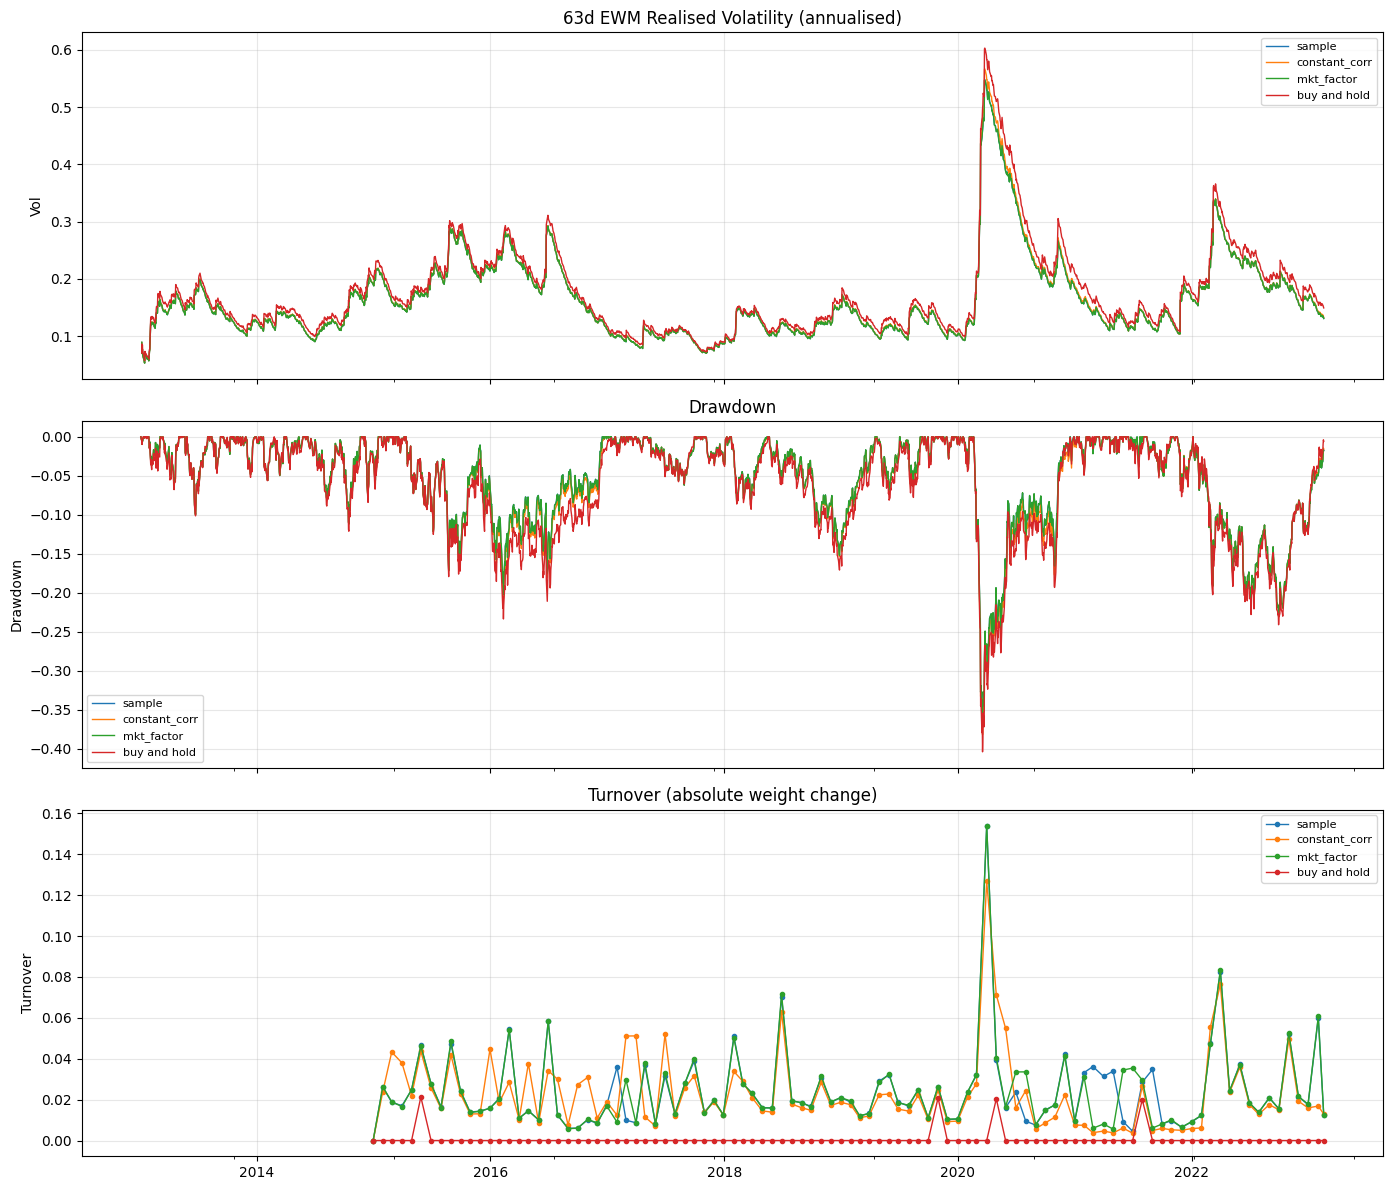


ERC Portfolio Metrics:
               Cumulative Return  Ann. Vol (EWM 63d, mean)  Max Drawdown  \
sample                    2.7028                    0.1634       -0.3727   
constant_corr             2.6640                    0.1645       -0.3820   
mkt_factor                2.7058                    0.1633       -0.3721   
buy and hold              2.7014                    0.1756       -0.4040   

               Avg Turnover  
sample               0.0243  
constant_corr        0.0227  
mkt_factor           0.0241  
buy and hold         0.0008  


In [8]:
# Daily returns for each ERC estimator (needed for vol and drawdown)
erc_daily_ret = {
    "sample":        portfolio_returns(erc_dfs["sample"].fillna(0), performance, transaction_costs=10e-4),
    "constant_corr": portfolio_returns(erc_dfs["constant_corr"].fillna(0), performance, transaction_costs=10e-4),
    "mkt_factor":    portfolio_returns(erc_dfs["mkt_factor"].fillna(0), performance, transaction_costs=10e-4),
    "buy and hold":  portfolio_returns(erc_dfs["buy and hold"].fillna(0), performance, transaction_costs=10e-4),
}

def ewm_realized_vol_63d(ret, trading_days=252):
    return ret.ewm(span=63).std() * np.sqrt(trading_days)

def drawdown_series(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.expanding().max()) / cum.expanding().max()

def compute_turnover(weights_df):
    return weights_df.diff().abs().sum(axis=1)

# Time series plots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1) 63d EWM realized vol
for est_name, ret in erc_daily_ret.items():
    ewm_realized_vol_63d(ret).plot(ax=axes[0], label=est_name, linewidth=1)
axes[0].set_title("63d EWM Realised Volatility (annualised)")
axes[0].set_ylabel("Vol"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Drawdown
for est_name, ret in erc_daily_ret.items():
    drawdown_series(ret).plot(ax=axes[1], label=est_name, linewidth=1)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown"); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Turnover (at rebalance dates)
for est_name, wdf in erc_dfs.items():
    compute_turnover(wdf).dropna().plot(ax=axes[2], label=est_name, linewidth=1, marker='.')
axes[2].set_title("Turnover (absolute weight change)")
axes[2].set_ylabel("Turnover"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
metrics = {}
for est_name in erc_daily_ret:
    ret = erc_daily_ret[est_name]
    metrics[est_name] = {
        "Cumulative Return":        (1 + ret).cumprod().iloc[-1],
        "Ann. Vol (EWM 63d, mean)": ewm_realized_vol_63d(ret).mean(),
        "Max Drawdown":             drawdown_series(ret).min(),
        "Avg Turnover":             compute_turnover(erc_dfs[est_name]).mean(),
    }

metrics_df = pd.DataFrame(metrics).T
print("\nERC Portfolio Metrics:")
print(metrics_df.round(4))

## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


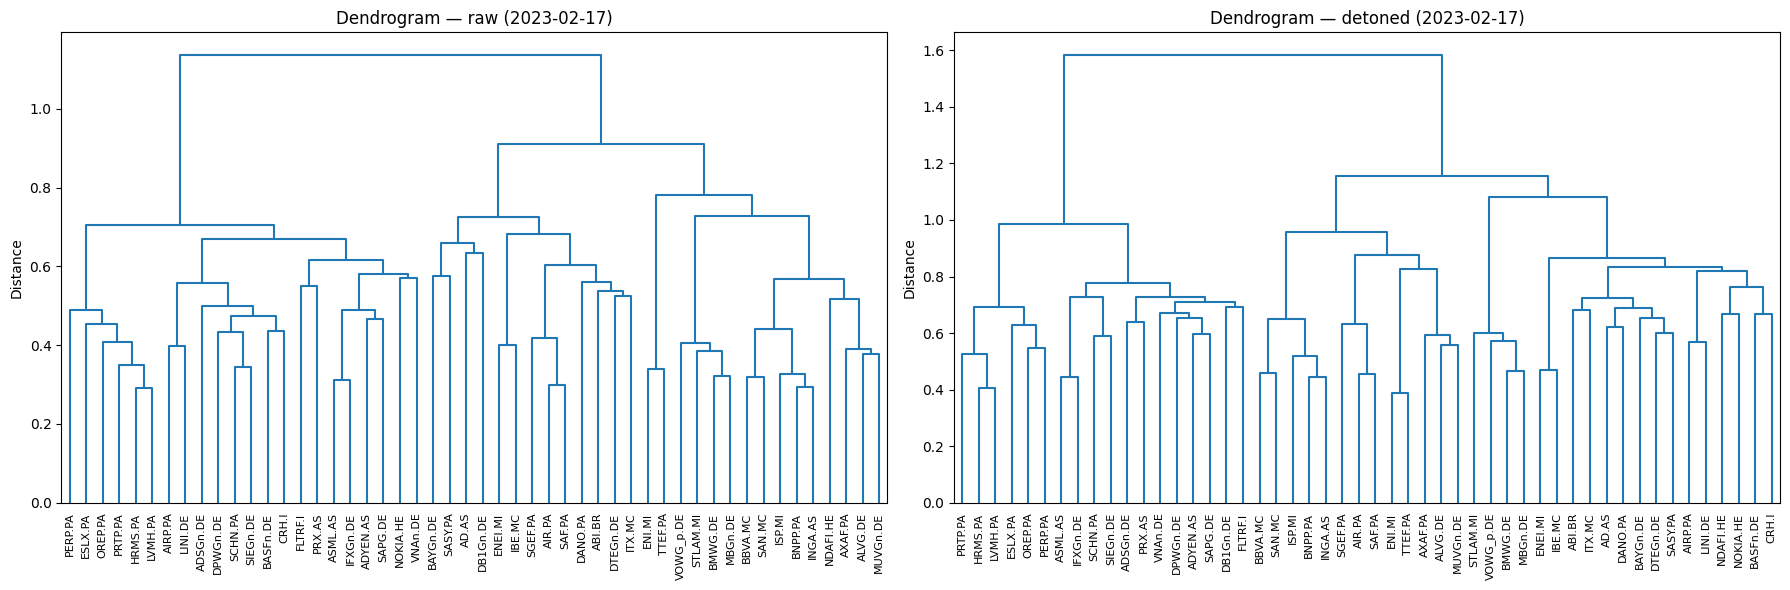

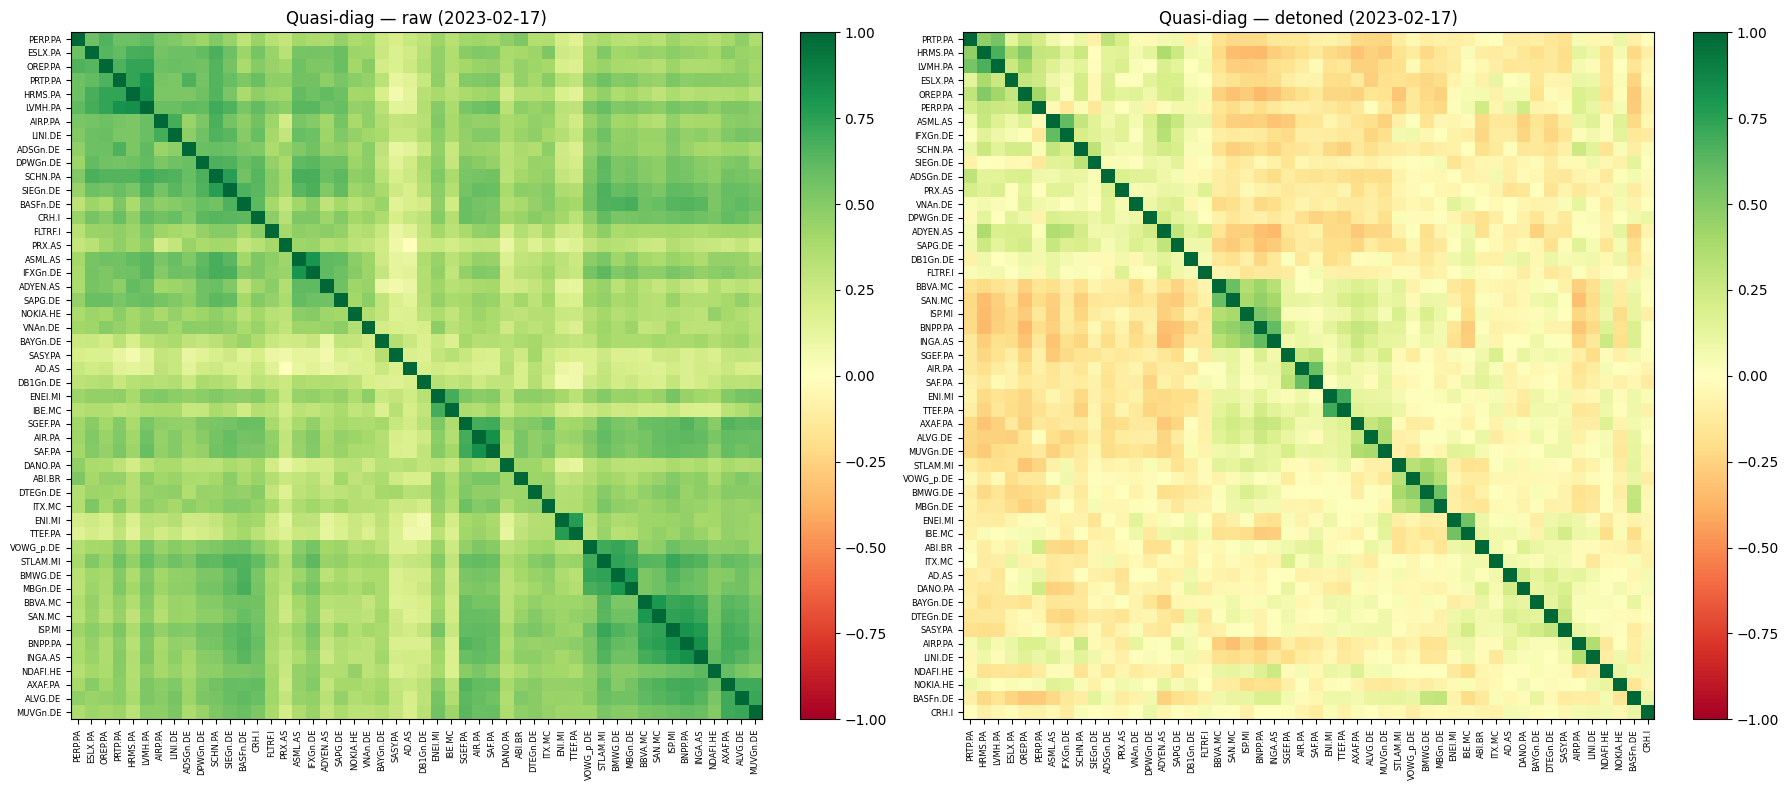

In [ ]:
last_date = all_dates[-1]
cov_last = covariances[last_date]["sample"]
tickers = list(cov_last.index)

# corr → distance → clustering
corr_raw = covariance_to_correlation(cov_last.values)
dist_raw = correlation_to_hrp_distance(corr_raw)
dist_raw_df = pd.DataFrame(dist_raw, index=cov_last.index, columns=cov_last.columns)
link_raw = hierarchical_clustering(dist_raw_df, linkage_method="ward", distance_metric="euclidean")

# Detoned: corr → detone → distance → clustering
corr_det = detone(corr_raw.copy(), components_num=1)
dist_det = correlation_to_hrp_distance(corr_det)
dist_det_df = pd.DataFrame(dist_det, index=cov_last.index, columns=cov_last.columns)
link_det = hierarchical_clustering(dist_det_df, linkage_method="ward", distance_metric="euclidean")

# Dendrograms
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, lnk, ttl in [
    (axes[0], link_raw, f"Dendrogram — raw ({last_date})"),
    (axes[1], link_det, f"Dendrogram — detoned ({last_date})"),
]:
    sch.dendrogram(lnk.values, labels=tickers, color_threshold=0,
                   leaf_rotation=90, ax=ax)
    ax.set_title(ttl); ax.set_ylabel("Distance")
plt.tight_layout(); plt.show()

# Quasi-diagonalized heatmaps
order_raw = sch.leaves_list(link_raw.values)
order_det = sch.leaves_list(link_det.values)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, corr, order, ttl in [
    (axes[0], corr_raw, order_raw, f"Quasi-diag — raw ({last_date})"),
    (axes[1], corr_det, order_det, f"Quasi-diag — detoned ({last_date})"),
]:
    ordered = corr[np.ix_(order, order)]
    labs = [tickers[i] for i in order]
    im = ax.imshow(ordered, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90, fontsize=6)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=6)
    ax.set_title(ttl); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


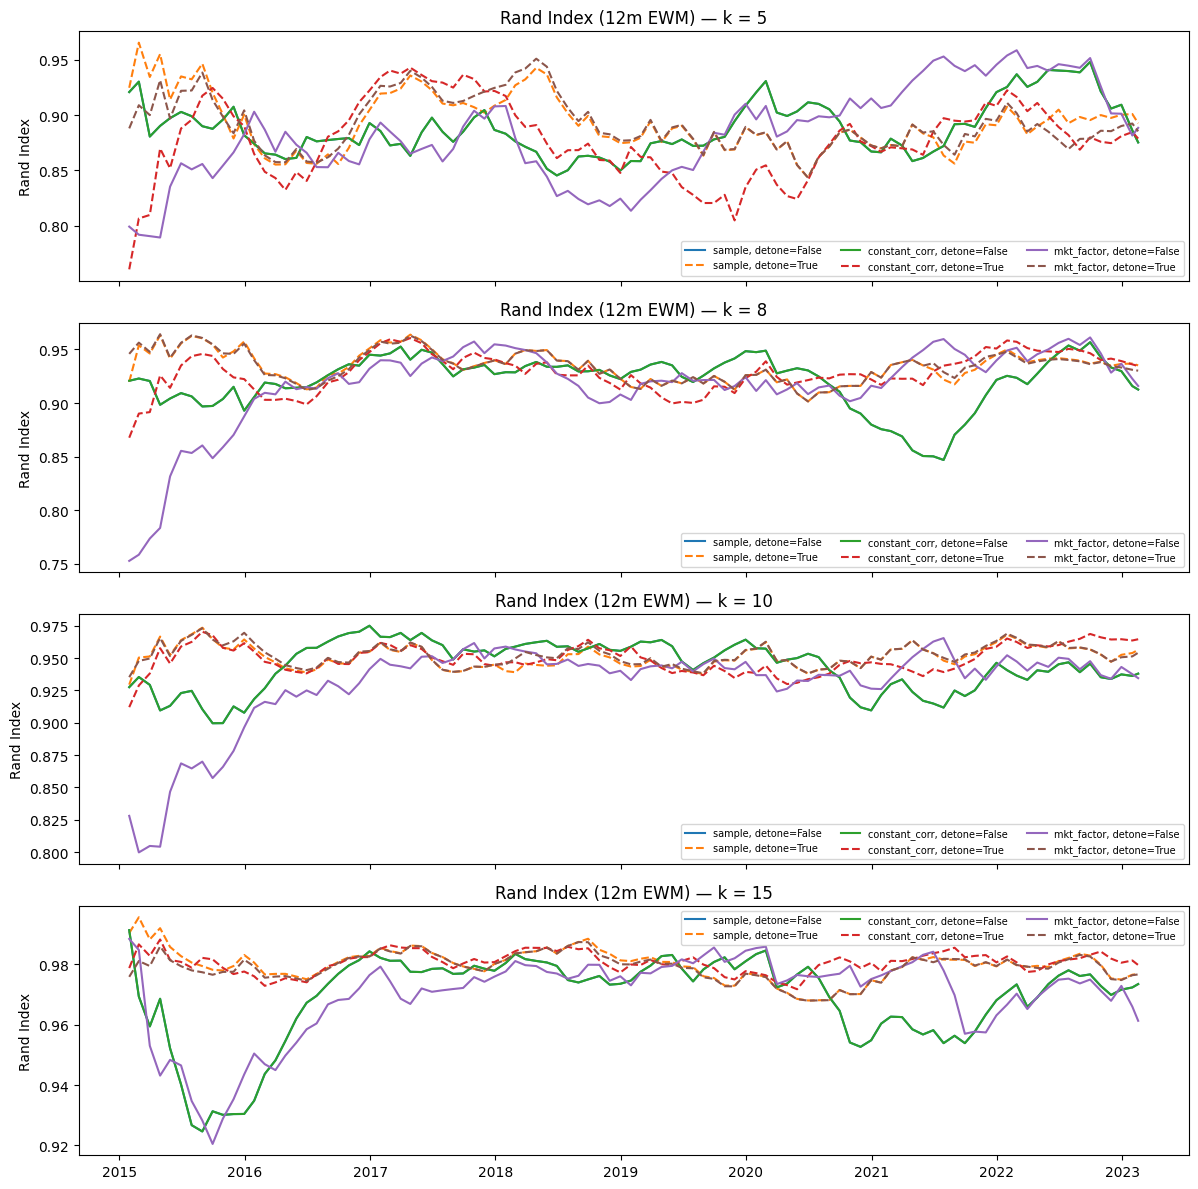

In [ ]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:
            #corr → (detone) → HRP distance → linkage
            corr = covariance_to_correlation(cov.values)
            if detone_flag:
                corr = detone(corr_matrix=corr.copy(), components_num=1)
            dist = correlation_to_hrp_distance(corr)
            dist_df = pd.DataFrame(dist, index=cov.index, columns=cov.columns)
            link = hierarchical_clustering(
                matrix=dist_df,
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
            )
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )

#Rand Index between consecutive rebalances
rand_indices = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}
for c in COV_KEYS:
    for d in DETONE_KEYS:
        for k in N_CLUSTERS_GRID:
            for i in range(1, len(all_dates)):
                prev = clusters[(c, d, k)][all_dates[i - 1]]
                curr = clusters[(c, d, k)][all_dates[i]]
                common = prev.index.intersection(curr.index)
                if len(common) > 1:
                    rand_indices[(c, d, k)][all_dates[i]] = rand_score(
                        prev.loc[common].values, curr.loc[common].values
                    )

#  Plot
fig, axes = plt.subplots(len(N_CLUSTERS_GRID), 1,
                         figsize=(12, 3 * len(N_CLUSTERS_GRID)), sharex=True)
for ax, k in zip(axes, N_CLUSTERS_GRID):
    for c in COV_KEYS:
        for d in DETONE_KEYS:
            ri = pd.Series(rand_indices[(c, d, k)])
            ri.index = pd.DatetimeIndex(ri.index)
            ax.plot(ri.ewm(span=12).mean(), linestyle="--" if d else "-",
                    label=f"{c}, detone={d}")
    ax.set_title(f"Rand Index (12m EWM) — k = {k}")
    ax.set_ylabel("Rand Index")
    ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [ ]:
from utilities.hierarchical_risk_parity import (
    top_down_allocation, get_cluster_var_via_iv, list_recursive_bisection,
)
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch

LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}



def _flatten(lst):
    if isinstance(lst, list):
        out = []
        for x in lst:
            out.extend(_flatten(x))
        return out
    return [lst]

def _is_nested(lst):
    return any(isinstance(x, list) for x in lst)

def _top_down_fast(nc, cov_arr, l2i):
    """Numpy-only top-down allocation — equivalent to top_down_allocation but
    operates on raw arrays instead of pd.DataFrame.loc slicing (~89x faster)."""
    n = len(l2i)
    weights = np.ones(n)
    def _r(nc):
        if not _is_nested(nc):
            return
        c1 = _flatten(nc[0]); c2 = _flatten(nc[1])
        i1 = [l2i[l] for l in c1]; i2 = [l2i[l] for l in c2]
        s1 = cov_arr[np.ix_(i1, i1)]
        iv1 = 1.0 / np.diag(s1); iv1 /= iv1.sum()
        var1 = iv1 @ s1 @ iv1
        s2 = cov_arr[np.ix_(i2, i2)]
        iv2 = 1.0 / np.diag(s2); iv2 /= iv2.sum()
        var2 = iv2 @ s2 @ iv2
        a1 = var2 / (var1 + var2)
        for i in i1: weights[i] *= a1
        for i in i2: weights[i] *= (1 - a1)
        _r(nc[0]); _r(nc[1])
    _r(nc)
    return weights

def _dendrogram_from_Z(Z, n, labels):
    """Dendrogram traversal directly from raw linkage array Z (skips DataFrame)."""
    active = {i: [labels[i]] for i in range(n)}
    for i in range(len(Z)):
        idx1, idx2 = int(Z[i, 0]), int(Z[i, 1])
        active[n + i] = [active[idx1], active[idx2]]
        del active[idx1]; del active[idx2]
    return list(active.values())[0]

def _recursive_bisection_from_Z(Z, labels):
    """Recursive bisection directly from raw linkage array Z (skips DataFrame)."""
    leaves = sch.leaves_list(Z)
    return list_recursive_bisection(lst=[labels[l] for l in leaves], max_iter=None)

all_tickers = sorted(
    set(t for reb in all_dates for t in covariances[reb]["sample"].index)
)
ticker_to_gidx = {t: i for i, t in enumerate(all_tickers)}
n_tickers = len(all_tickers)
n_dates = len(all_dates)

result_arrays = {
    (ck, link, an, d): np.zeros((n_dates, n_tickers))
    for ck in COV_KEYS for link in LINK_GRID
    for an in ALLOC_GRID for d in DETONE_KEYS
}

for t_idx, reb in enumerate(all_dates):
    for ck in COV_KEYS:
        cov = covariances[reb][ck]
        labels = cov.index.tolist()
        n = len(labels)
        l2i = {l: i for i, l in enumerate(labels)}
        cov_arr = cov.values
        corr = covariance_to_correlation(cov_arr)

        for d in DETONE_KEYS:
            c = detone(corr_matrix=corr.copy(), components_num=1) if d else corr
            dist = correlation_to_hrp_distance(c)
            condensed = squareform(dist, checks=False)

            for link in LINK_GRID:
                Z = sch.linkage(condensed, method=link)

                for an_name in ALLOC_GRID:
                    if an_name == "dendrogram_iteration":
                        nc = _dendrogram_from_Z(Z, n, labels)
                    else:
                        nc = _recursive_bisection_from_Z(Z, labels)

                    w = _top_down_fast(nc, cov_arr, l2i)
                    gidx = [ticker_to_gidx[l] for l in labels]
                    result_arrays[(ck, link, an_name, d)][t_idx, gidx] = w

# Convert to DataFrames (needed by the plot cell)
date_index = pd.DatetimeIndex(all_dates)
hrp_grid = {}
for key, arr in result_arrays.items():
    df = pd.DataFrame(arr, index=date_index, columns=all_tickers)
    hrp_grid[key] = df.loc[:, (df != 0).any()]

# Metrics
rows = []
for key, ptf in hrp_grid.items():
    ck, link, an, d = key
    mean_to = ptf.diff().iloc[1:].abs().sum(axis=1).div(2).mean()
    mean_hhi = ptf.pow(2).sum(axis=1).mean()
    rows.append(dict(estimator=ck, linkage=link, allocator=an,
                     detone=d, mean_turnover=round(mean_to, 4),
                     mean_HHI=round(mean_hhi, 4)))

summary = pd.DataFrame(rows)
pivot = summary.groupby(["linkage", "allocator"])[["mean_turnover", "mean_HHI"]].mean()
print("HRP Sensitivity (averaged over estimators and detoning):")
print(pivot.round(4))


HRP Sensitivity (averaged over estimators and detoning):
                               mean_turnover  mean_HHI
linkage  allocator                                    
average  dendrogram_iteration         0.1408    0.1186
         recursive_bisection          0.1020    0.0270
complete dendrogram_iteration         0.1833    0.0642
         recursive_bisection          0.1157    0.0266
single   dendrogram_iteration         0.1388    0.1724
         recursive_bisection          0.1018    0.0270
ward     dendrogram_iteration         0.1805    0.0426
         recursive_bisection          0.1112    0.0266


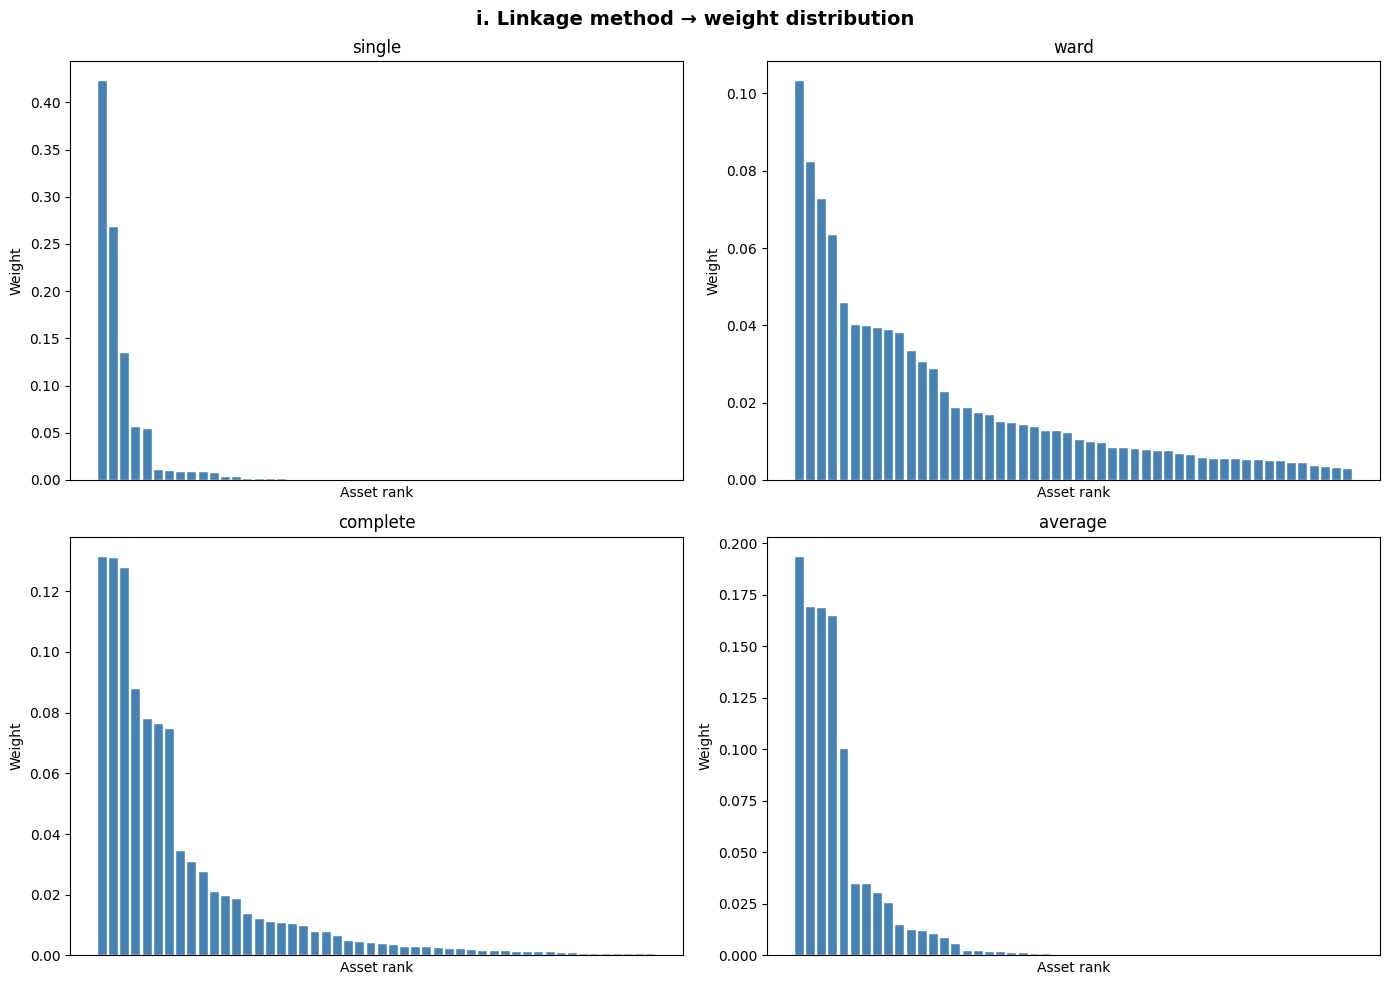

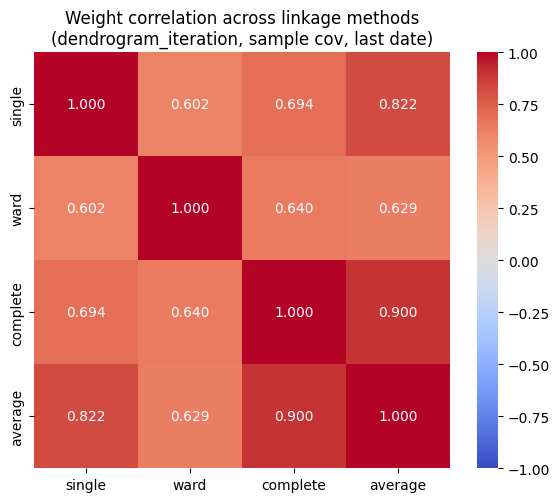

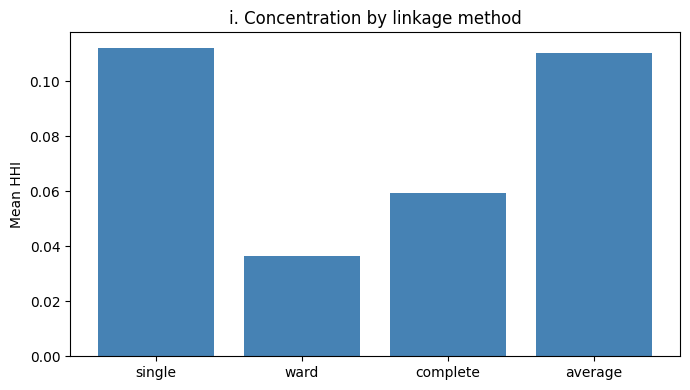

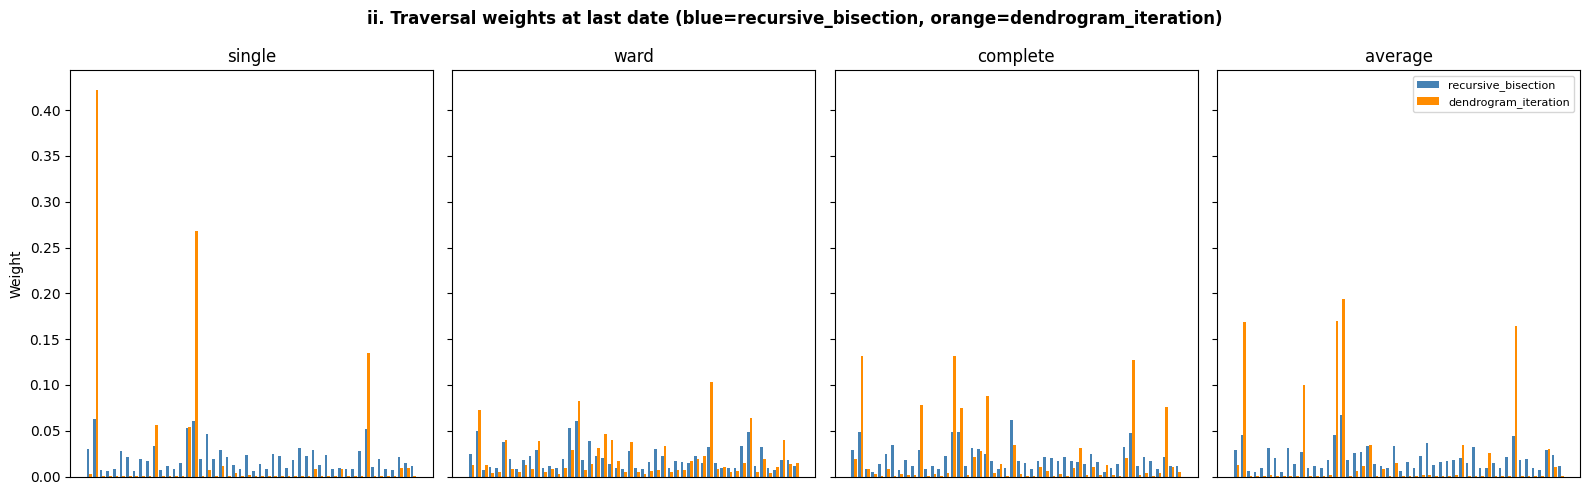

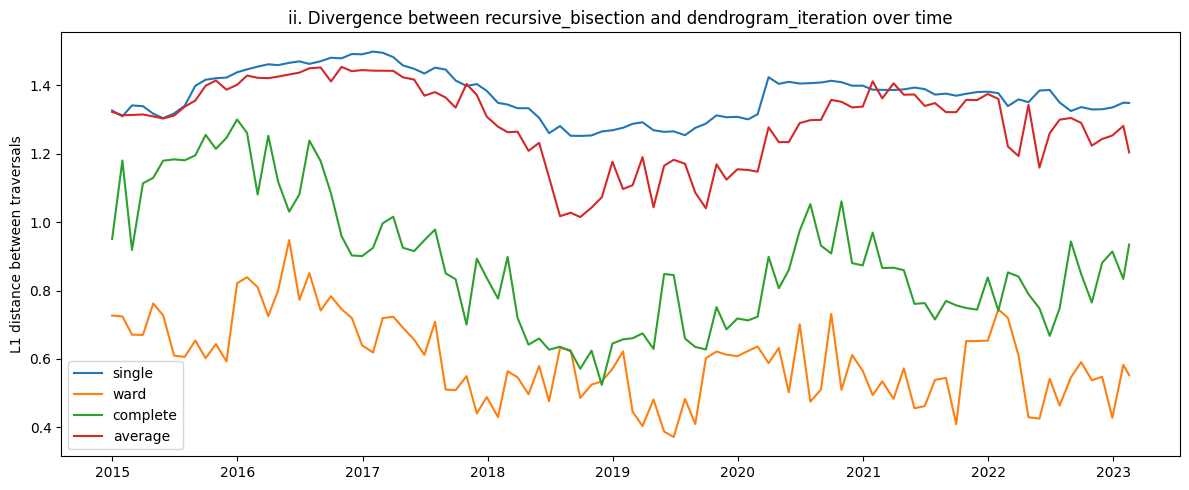

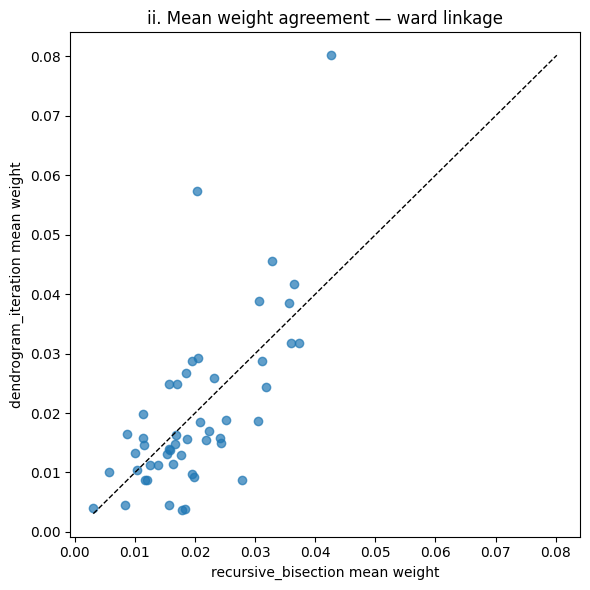


── Summary table (sorted by mean turnover) ──
        estimator   linkage             allocator  detone  mean_turnover  mean_HHI
0          sample    single   recursive_bisection   False         0.0892    0.0279
1          sample    single   recursive_bisection    True         0.1209    0.0264
2          sample    single  dendrogram_iteration   False         0.0803    0.1965
3          sample    single  dendrogram_iteration    True         0.1969    0.1458
4          sample      ward   recursive_bisection   False         0.1181    0.0270
5          sample      ward   recursive_bisection    True         0.1116    0.0265
6          sample      ward  dendrogram_iteration   False         0.1793    0.0463
7          sample      ward  dendrogram_iteration    True         0.1859    0.0382
8          sample  complete   recursive_bisection   False         0.1146    0.0270
9          sample  complete   recursive_bisection    True         0.1194    0.0266
10         sample  complete  dendrogram_

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

focus_cov   = "sample"
focus_d     = False
focus_date  = pd.Timestamp(all_dates[-1])

# i. Linkage effect on weights (fix alloc, cov, detone; vary link)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
fig.suptitle("i. Linkage method → weight distribution", fontsize=14, fontweight="bold")

for ax, link in zip(axes.flat, LINK_GRID):
    w = hrp_grid[(focus_cov, link, "dendrogram_iteration", focus_d)].loc[focus_date]
    w_sorted = w.sort_values(ascending=False)
    ax.bar(range(len(w_sorted)), w_sorted.values, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_title(link)
    ax.set_xlabel("Asset rank")
    ax.set_ylabel("Weight")
    ax.set_xticks([])

plt.tight_layout()
plt.show()

# Weight correlation across linkages (heatmap)
weight_df_link = pd.DataFrame({
    link: hrp_grid[(focus_cov, link, "dendrogram_iteration", focus_d)].loc[focus_date]
    for link in LINK_GRID
})
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(weight_df_link.corr(), annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Weight correlation across linkage methods\n(dendrogram_iteration, sample cov, last date)")
plt.tight_layout()
plt.show()

# Mean HHI by linkage
fig, ax = plt.subplots(figsize=(7, 4))
hhi_by_link = (
    summary.query("estimator == @focus_cov and detone == @focus_d")
           .groupby("linkage")["mean_HHI"]
           .mean()
           .reindex(LINK_GRID)
)
ax.bar(hhi_by_link.index, hhi_by_link.values, color="steelblue")
ax.set_ylabel("Mean HHI")
ax.set_title("i. Concentration by linkage method")
plt.tight_layout()
plt.show()

# Side-by-side weights at last date for each linkage
fig, axes = plt.subplots(1, len(LINK_GRID), figsize=(16, 5), sharey=True)
fig.suptitle("ii. Traversal weights at last date (blue=recursive_bisection, orange=dendrogram_iteration)",
             fontsize=12, fontweight="bold")

assets = hrp_grid[(focus_cov, LINK_GRID[0], "recursive_bisection", focus_d)].columns
for ax, link in zip(axes, LINK_GRID):
    w_rb = hrp_grid[(focus_cov, link, "recursive_bisection",  focus_d)].loc[focus_date]
    w_di = hrp_grid[(focus_cov, link, "dendrogram_iteration", focus_d)].loc[focus_date]
    x = np.arange(len(assets))
    ax.bar(x - 0.2, w_rb.values, width=0.4, label="recursive_bisection",  color="steelblue")
    ax.bar(x + 0.2, w_di.values, width=0.4, label="dendrogram_iteration", color="darkorange")
    ax.set_title(link)
    ax.set_xticks([])

axes[0].set_ylabel("Weight")
axes[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# L1 distance between traversals over time, by linkage
fig, ax = plt.subplots(figsize=(12, 5))
for link in LINK_GRID:
    w_rb = hrp_grid[(focus_cov, link, "recursive_bisection",  focus_d)]
    w_di = hrp_grid[(focus_cov, link, "dendrogram_iteration", focus_d)]
    l1   = (w_rb - w_di).abs().sum(axis=1)
    ax.plot(l1.index, l1.values, label=link)

ax.set_ylabel("L1 distance between traversals")
ax.set_title("ii. Divergence between recursive_bisection and dendrogram_iteration over time")
ax.legend()
plt.tight_layout()
plt.show()

# Scatter: traversal weight agreement per asset (ward focus)
focus_link = "ward"
w_rb = hrp_grid[(focus_cov, focus_link, "recursive_bisection",  focus_d)].mean()
w_di = hrp_grid[(focus_cov, focus_link, "dendrogram_iteration", focus_d)].mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(w_rb, w_di, alpha=0.7)
lims = [min(w_rb.min(), w_di.min()), max(w_rb.max(), w_di.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("recursive_bisection mean weight")
ax.set_ylabel("dendrogram_iteration mean weight")
ax.set_title(f"ii. Mean weight agreement — {focus_link} linkage")
plt.tight_layout()
plt.show()

# Summary table print
print("\n── Summary table (sorted by mean turnover) ──")
print(summary.to_string())

## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

In [13]:
HRP_LINK  = "ward"
HRP_ALLOC = "dendrogram_iteration"
HRP_DET   = False

est_pairs = [("sample", "constant_corr"),
             ("sample", "mkt_factor"),
             ("constant_corr", "mkt_factor")]

# Build aligned weight DataFrames for each estimator (ERC & HRP)
# so we can compute L1 distances as a single vectorised abs().sum(axis=1)
erc_aligned = {
    est: pd.DataFrame(erc_portfolios[est]).T.fillna(0) for est in COV_KEYS
}
hrp_aligned = {
    est: hrp_grid[(est, HRP_LINK, HRP_ALLOC, HRP_DET)].fillna(0)
    for est in COV_KEYS
}

print(f"{'Pair':<35} {'ERC':>10} {'HRP':>10}")
print("-" * 57)
for e1, e2 in est_pairs:
    # align columns (union of assets), missing weights = 0
    all_cols = erc_aligned[e1].columns.union(erc_aligned[e2].columns)
    erc_l1 = (erc_aligned[e1].reindex(columns=all_cols, fill_value=0)
              - erc_aligned[e2].reindex(columns=all_cols, fill_value=0)
             ).abs().sum(axis=1).mean()

    all_cols_h = hrp_aligned[e1].columns.union(hrp_aligned[e2].columns)
    hrp_l1 = (hrp_aligned[e1].reindex(columns=all_cols_h, fill_value=0)
              - hrp_aligned[e2].reindex(columns=all_cols_h, fill_value=0)
             ).abs().sum(axis=1).mean()

    print(f"{str((e1, e2)):<35} {erc_l1:>10.4f} {hrp_l1:>10.4f}")

Pair                                       ERC        HRP
---------------------------------------------------------
('sample', 'constant_corr')             0.0331     0.0328
('sample', 'mkt_factor')                0.0056     0.2855
('constant_corr', 'mkt_factor')         0.0341     0.2976


### 3.b ERC vs HRP — performance, vol, drawdown, turnover



── 3.b  ERC vs HRP — metriche di performance ──
                     Ann. Vol EWM63 (%)  Sharpe  Max Drawdown (%)  Avg Turnover
Strategy                                                                       
ERC — sample                      16.34   0.631            -37.27        0.0243
HRP — sample                      15.07   0.610            -31.11        0.3549
ERC — constant_corr               16.45   0.619            -38.20        0.0227
HRP — constant_corr               15.18   0.600            -32.09        0.3574
ERC — mkt_factor                  16.33   0.632            -37.21        0.0241
HRP — mkt_factor                  14.95   0.723            -30.40        0.3406
Buy and Hold                      17.56   0.598            -40.40        0.0008


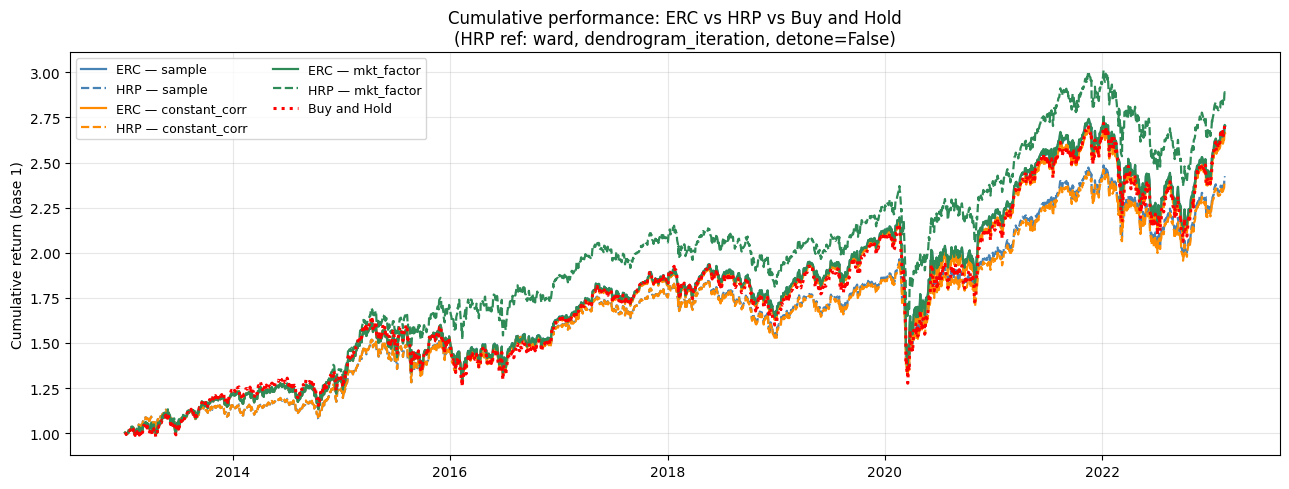

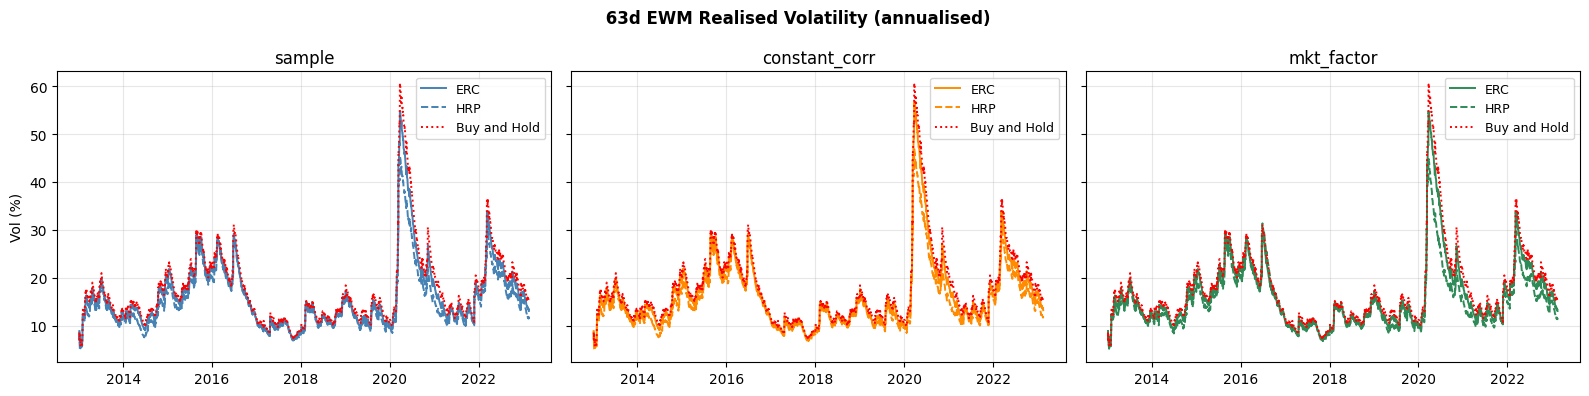

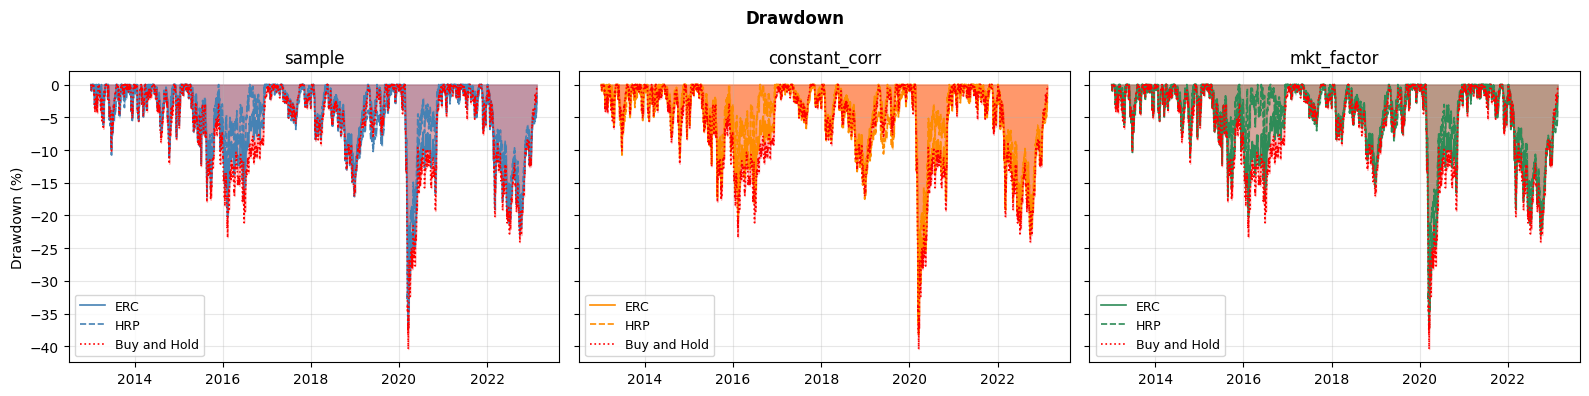

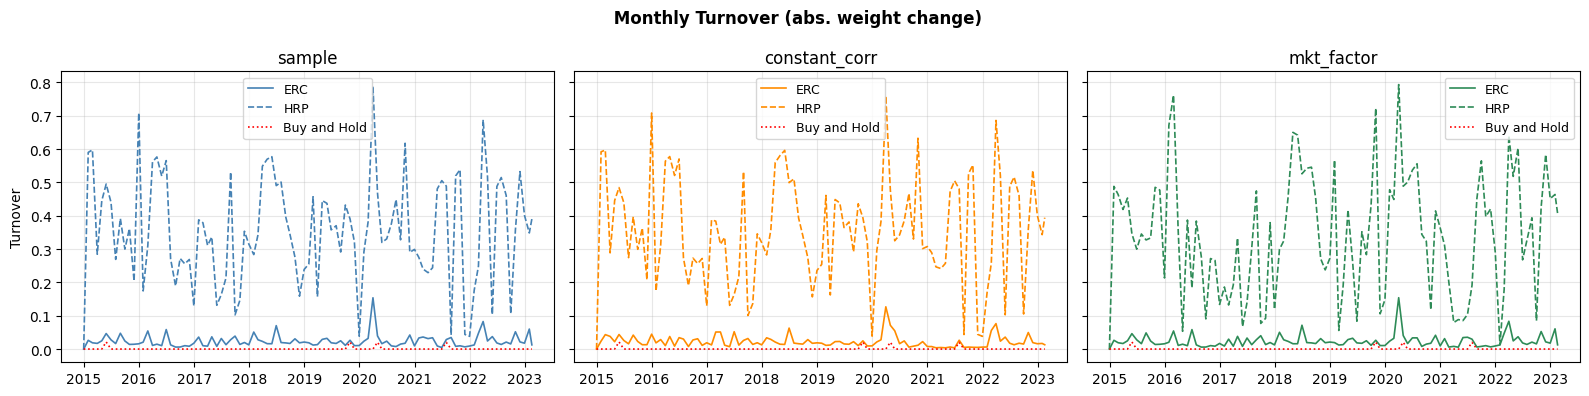

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


HRP_LINK  = "ward"
HRP_ALLOC = "dendrogram_iteration"
HRP_DET   = False



def ewm_realized_vol_63d(ret: pd.Series, trading_days: int = 252) -> pd.Series:
    """
    63-day EWM realised volatility, annualised.
    span=63 means the half-life is ~31 trading days, consistent with 1.c.
    """
    return ret.ewm(span=63).std() * np.sqrt(trading_days)

def drawdown_series(ret: pd.Series) -> pd.Series:
    """Drawdown time series from a daily return series."""
    cum = (1 + ret).cumprod()
    return (cum - cum.expanding().max()) / cum.expanding().max()

def max_drawdown(ret: pd.Series) -> float:
    return float(drawdown_series(ret).min())

def avg_turnover(weights_df: pd.DataFrame) -> float:
    """Media mensile delle somme delle variazioni assolute dei pesi (one-way)."""
    return float(weights_df.diff().abs().sum(axis=1).mean())

def annualized_sharpe(ret: pd.Series, trading_days: int = 252) -> float:
    vol = ret.std()
    return float((ret.mean() / vol) * np.sqrt(trading_days)) if vol > 0 else np.nan

def portfolio_ret(weights_df: pd.DataFrame) -> pd.Series:
    """Rendimenti giornalieri del portafoglio dal DataFrame dei pesi mensili."""
    return portfolio_returns(weights_df.fillna(0), performance , transaction_costs=10e-4)

#series of returns for each strategy, plus the weights DataFrame for turnover calculation
strategies = {}

for est in COV_KEYS:
    # ERC — already computed in 3.a, just need to align and fill missing weights with 0
    strategies[f"ERC — {est}"] = {
        "ret":     portfolio_ret(erc_dfs[est]),
        "weights": erc_dfs[est],
    }
    # HRP — choice of parameters from previous analysis, align and fill missing weights with 0
    hrp_w = hrp_grid[(est, HRP_LINK, HRP_ALLOC, HRP_DET)].fillna(0)
    strategies[f"HRP — {est}"] = {
        "ret":     portfolio_ret(hrp_w),
        "weights": hrp_w,
    }

# Add Buy and Hold baseline
strategies["Buy and Hold"] = {
    "ret":     portfolio_ret(erc_dfs["buy and hold"]),
    "weights": erc_dfs["buy and hold"],
}

records = []
for name, d in strategies.items():
    ret = d["ret"]
    records.append({
        "Strategy":             name,
        "Ann. Vol EWM63 (%)":   round(ewm_realized_vol_63d(ret).mean() * 100, 2),
        "Sharpe":               round(annualized_sharpe(ret), 3),
        "Max Drawdown (%)":     round(max_drawdown(ret) * 100, 2),
        "Avg Turnover":         round(avg_turnover(d["weights"]), 4),
    })

metrics_3b = pd.DataFrame(records).set_index("Strategy")
print("\n── 3.b  ERC vs HRP — metriche di performance ──")
print(metrics_3b.to_string())


colors_est  = {"sample": "steelblue", "constant_corr": "darkorange", "mkt_factor": "seagreen", "Buy and Hold": "red"}
linestyles  = {"ERC": "-", "HRP": "--", "Buy and Hold": ":"}

# Plot 1: Cumulative returns
cum_rets = pd.DataFrame({
    name: (1 + d["ret"]).cumprod()
    for name, d in strategies.items()
})

fig, ax = plt.subplots(figsize=(13, 5))
for col in cum_rets.columns:
    if col == "Buy and Hold":
        ax.plot(cum_rets.index, cum_rets[col],
                linestyle=linestyles["Buy and Hold"],
                color=colors_est["Buy and Hold"],
                linewidth=2.2, label=col)
    else:
        strat_type, est = col.split(" — ")
        ax.plot(cum_rets.index, cum_rets[col],
                linestyle=linestyles[strat_type],
                color=colors_est[est],
                linewidth=1.6, label=col)
ax.set_title(
    "Cumulative performance: ERC vs HRP vs Buy and Hold\n"
    f"(HRP ref: {HRP_LINK}, {HRP_ALLOC}, detone={HRP_DET})"
)
ax.set_ylabel("Cumulative return (base 1)")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: 63d EWM realised volatility (annualised)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle(" 63d EWM Realised Volatility (annualised)", fontsize=12, fontweight="bold")

for ax, est in zip(axes, COV_KEYS):
    for strat_type, ls in [("ERC", "-"), ("HRP", "--")]:
        name = f"{strat_type} — {est}"
        ewm_vol = ewm_realized_vol_63d(strategies[name]["ret"])
        ax.plot(ewm_vol.index, ewm_vol * 100,
                linestyle=ls, color=colors_est[est], linewidth=1.4, label=strat_type)
    # Add Buy and Hold for each subplot
    ewm_vol_bh = ewm_realized_vol_63d(strategies["Buy and Hold"]["ret"])
    ax.plot(ewm_vol_bh.index, ewm_vol_bh * 100,
            linestyle=":", color=colors_est["Buy and Hold"], linewidth=1.4, label="Buy and Hold")
    ax.set_title(est)
    ax.set_ylabel("Vol (%)" if ax == axes[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Drawdown
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle("Drawdown", fontsize=12, fontweight="bold")

for ax, est in zip(axes, COV_KEYS):
    for strat_type, ls in [("ERC", "-"), ("HRP", "--")]:
        name = f"{strat_type} — {est}"
        dd = drawdown_series(strategies[name]["ret"])
        ax.fill_between(dd.index, dd * 100, 0,
                        alpha=0.25, color=colors_est[est])
        ax.plot(dd.index, dd * 100,
                linestyle=ls, color=colors_est[est], linewidth=1.2, label=strat_type)
    # Add Buy and Hold for each subplot
    dd_bh = drawdown_series(strategies["Buy and Hold"]["ret"])
    ax.fill_between(dd_bh.index, dd_bh * 100, 0,
                    alpha=0.25, color=colors_est["Buy and Hold"])
    ax.plot(dd_bh.index, dd_bh * 100,
            linestyle=":", color=colors_est["Buy and Hold"], linewidth=1.2, label="Buy and Hold")
    ax.set_title(est)
    ax.set_ylabel("Drawdown (%)" if ax == axes[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 4: Turnover in time
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle(" Monthly Turnover (abs. weight change)", fontsize=12, fontweight="bold")

for ax, est in zip(axes, COV_KEYS):
    for strat_type, ls in [("ERC", "-"), ("HRP", "--")]:
        name   = f"{strat_type} — {est}"
        to_ser = strategies[name]["weights"].diff().abs().sum(axis=1).dropna()
        ax.plot(to_ser.index, to_ser,
                linestyle=ls, color=colors_est[est], linewidth=1.2, label=strat_type)
    # Add Buy and Hold for each subplot
    to_ser_bh = strategies["Buy and Hold"]["weights"].diff().abs().sum(axis=1).dropna()
    ax.plot(to_ser_bh.index, to_ser_bh,
            linestyle=":", color=colors_est["Buy and Hold"], linewidth=1.2, label="Buy and Hold")
    ax.set_title(est)
    ax.set_ylabel("Turnover" if ax == axes[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
